## <center> Telco Customer Churn </center>

Project link: https://www.kaggle.com/datasets/alfathterry/telco-customer-churn-11-1-3 

### <b> Description </b>

The challange is to create a model based on the data that can predict whether a customer will Churn or not. It is a binary classification problem.


### <b> Data </b>

This telco customer churn data, is a fictional dataset of a telecom company that provided home phone and internet services to 7043 
customers in California in Q3. This dataset indicates which customers have left, stayed or signed up for their service. 
The target features is Churned and other feature relating to it is satisfaction score, churn score, and customer lifetime value (CLTV) index.


In [1]:
#!pip3 install kagglehub

In [2]:
#pip install --upgrade pip

In [3]:
#!pip3 install missingno

#### Importing the necessary libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#### Creating a histogram function that helps me histogram the numeric columns

In [5]:
def plot_distribution(df_churned,df_not_churned, col):
    """
    Automates the histogramming process:

    df_churned- the dataframe of the churned column
    df_not_churned- the dataframe of the unchurned column
    col- the col you want the data for 
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    # creating a overlapping distribution (histogram ) at left and box plot at the right
    axes[0].hist(df_not_churned[col].dropna(), bins='auto',edgecolor='none',color='steelblue',alpha=0.5, label='Not Churned', density= True)
    axes[0].hist(df_churned[col].dropna(),bins='auto',color='coral',alpha=0.6, edgecolor='none',label='Churned', density=True)
    axes[0].axvline(df_churned[col].mean(),color='coral',linestyle='--')# draws a vertical line at the mean
    axes[0].axvline(df_not_churned[col].mean(), color='steelblue', linestyle='--') # draws a vertical line at mean
    axes[0].set_title(f'{col}')
    axes[0].legend()

    #creating ther boxplot at the right
    axes[1].boxplot([df_churned[col].dropna(),df_not_churned[col].dropna()],tick_labels=['Churned', 'Not Churned'],vert=False)        #creates a horizontal box plot(note: it drops the null values)
    axes[1].set_title(f'{col} Boxplot')

    plt.tight_layout()
    plt.show()

    #Concise stats table
    desc_c=df_churned[col].describe()
    desc_n=df_not_churned[col].describe()
    print(f"{'':12}{'Churned':>10}{'Not Churned':>12}")
    print('-'*36)
    for stat in ['mean','std','min','50%','max']:
        print(f"{stat:12}{desc_c[stat]:>10.2f}{desc_n[stat]:>12.2f}")
    print()


#### Importing the dataset from kaggle

In [6]:

import kagglehub
from kagglehub import KaggleDatasetAdapter


file_path = "telco.csv" 

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "alfathterry/telco-customer-churn-11-1-3",
    file_path,  
)

print("First 5 records:", df.head())


/var/folders/k6/dk7cqd9513v3sf54fjc78_fr0000gn/T/ipykernel_85032/3185900193.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:   Customer ID  Gender  Age Under 30 Senior Citizen Married Dependents  \
0  8779-QRDMV    Male   78       No            Yes      No         No   
1  7495-OOKFY  Female   74       No            Yes     Yes        Yes   
2  1658-BYGOY    Male   71       No            Yes      No        Yes   
3  4598-XLKNJ  Female   78       No            Yes     Yes        Yes   
4  4846-WHAFZ  Female   80       No            Yes     Yes        Yes   

   Number of Dependents        Country       State  ...  \
0                     0  United States  California  ...   
1                     1  United States  California  ...   
2                     3  United States  California  ...   
3                     1  United States  California  ...   
4                     1  United States  California  ...   

  Total Extra Data Charges  Total Long Distance Charges  Total Revenue  \
0                       20                         0.00          59.65   
1                        0               

#### Saving the dataset into a local file

In [7]:
#saving the file to the local folder
df.to_csv("telco.csv", index=False) 

#### Exploring the dataset

In [8]:
df=pd.read_csv("telco.csv")
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [9]:
#checking the information of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

#### Rows and Features
Rows: 7043
Columns: 50

---

#### Our target variable is churned, So first lets create 2 dataframes one of churned people data and one of not churned people data

In [10]:
df_churned=df[df['Churn Label']=='Yes']
df_not_churned=df[df['Churn Label']=='No']

### Class Imbalance Check 

#### First lets examine different classes, to see if there is class balance or class imbalance

Class Distribution:
------------------------------
 No         5174 (73.5%)
 Yes        1869 (26.5%)


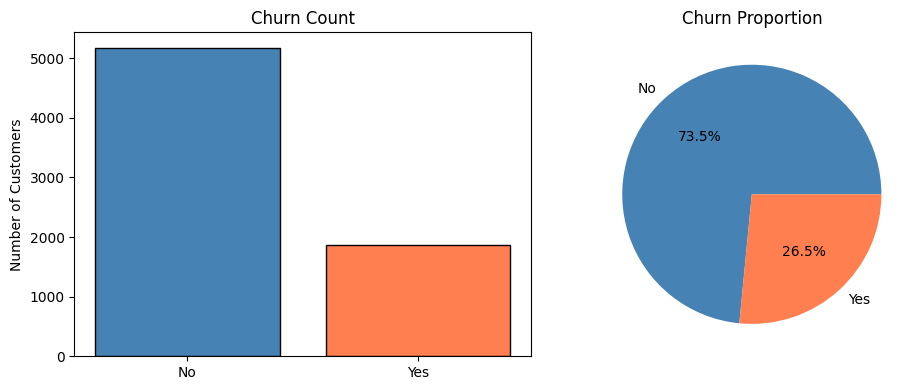

In [11]:
churn_counts=df['Churn Label'].value_counts()
churn_percentage=df['Churn Label'].value_counts(normalize=True) * 100

print('Class Distribution:')
print("-"* 30)

for label in churn_counts.index:
    print(f" {label:10}{churn_counts[label]:>5} ({churn_percentage[label]:.1f}%)")

#visuals
fig, axes= plt.subplots(1,2,figsize=(10,4))

axes[0].bar(churn_counts.index, churn_counts.values, color=['steelblue','coral'],edgecolor='black')
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Number of Customers')

#pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, colors=['steelblue','coral'], autopct='%1.1f%%')
axes[1].set_title('Churn Proportion')

plt.tight_layout()
plt.show()

#### Here we can see the number of people who didnot churn is around ~2.8 * more than the people who churned


#### We have to handle it before training the model

---

### Missing Value Check

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [13]:
print(df.isnull().sum())

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

In [14]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
    'Dtype': df.dtypes
})

# Show ALL columns, not just missing ones (better for your feature table)
print(missing.sort_values('Missing Count', ascending=False))

                                   Missing Count  Missing %    Dtype
Churn Reason                                5174      73.46   object
Churn Category                              5174      73.46   object
Offer                                       3877      55.05   object
Internet Type                               1526      21.67   object
Payment Method                                 0       0.00   object
Device Protection Plan                         0       0.00   object
Premium Tech Support                           0       0.00   object
Streaming TV                                   0       0.00   object
Streaming Movies                               0       0.00   object
Streaming Music                                0       0.00   object
Unlimited Data                                 0       0.00   object
Contract                                       0       0.00   object
Paperless Billing                              0       0.00   object
Monthly Charge                    

In [15]:
df['Churn Category'].head()

0         Competitor
1         Competitor
2         Competitor
3    Dissatisfaction
4              Price
Name: Churn Category, dtype: object

In [16]:
df['Churn Reason'].head()

0    Competitor offered more data
1    Competitor made better offer
2    Competitor made better offer
3       Limited range of services
4              Extra data charges
Name: Churn Reason, dtype: object

##### Even if we see there are around 5174 empty rows in Churned Cateogory and Churned Reason, it have a significant reason. As there were 5174 people who didnot churn.

#### But as around 70% of this data is missing, and it only having information about the churned customers, its better to drop these columns

In [17]:
df['Offer'].head()

0        NaN
1    Offer E
2    Offer D
3    Offer C
4    Offer C
Name: Offer, dtype: object

#### Offer is the last marketing offer that the customer accepted, but around 55.5 % of the data is missing hence, imputing it will not be good


In [18]:
df['Internet Type'].head()

0            DSL
1    Fiber Optic
2    Fiber Optic
3    Fiber Optic
4    Fiber Optic
Name: Internet Type, dtype: object

In [19]:
df['Internet Type'].unique()

array(['DSL', 'Fiber Optic', 'Cable', nan], dtype=object)

In [20]:
df['Internet Type'].isna().sum()

np.int64(1526)

#### As 1526 values are missing in the internet Type column, lets fill the missing value with No Internet

---

#### Dropping high missing columns and imputing the values in the internet type

In [21]:
### Dropping the leakage and high missing columns
df=df.drop(columns=['Churn Reason','Churn Category','Offer'])




In [22]:
# Filling Internet Type with No internet
df['Internet Type']=df['Internet Type'].fillna('No Internet')


In [23]:
# Verification
print(df.isnull().sum().sum(),"missing values remaining")

0 missing values remaining


In [24]:
print(df.shape)

(7043, 47)


In [25]:
## Droping the columns with zero variance
zero_var=[col for col in df.columns if df[col].nunique() == 1 ]
print("Zero variance columns:",zero_var)


Zero variance columns: ['Country', 'State', 'Quarter']


#### Dropping the columns with zero variance

In [26]:
df=df.drop(columns=zero_var)

---

#### Outlier Detection

In [27]:
# first seperating the numerical and categorical column
numerical=df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical=df.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", len(numerical))
print(numerical)

print("\n Categorical features:",len(categorical))
print(categorical)

Numerical features: 19
['Age', 'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Churn Score', 'CLTV']

 Categorical features: 25
['Customer ID', 'Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'City', 'Referred a Friend', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Customer Status', 'Churn Label']


In [28]:
cols_to_skip=[
    #leakage columns- it is generated after churn happens
    'Churn',

    
    # geographic identifiers- high cardinality, not behavorial
    'Zip Code',
    'Latitude',
    'Longitude',

    # Pure ID column- no signal
    'Customer ID',

    # Perfectly encodes the target
    'Customer Status'
    
    ]

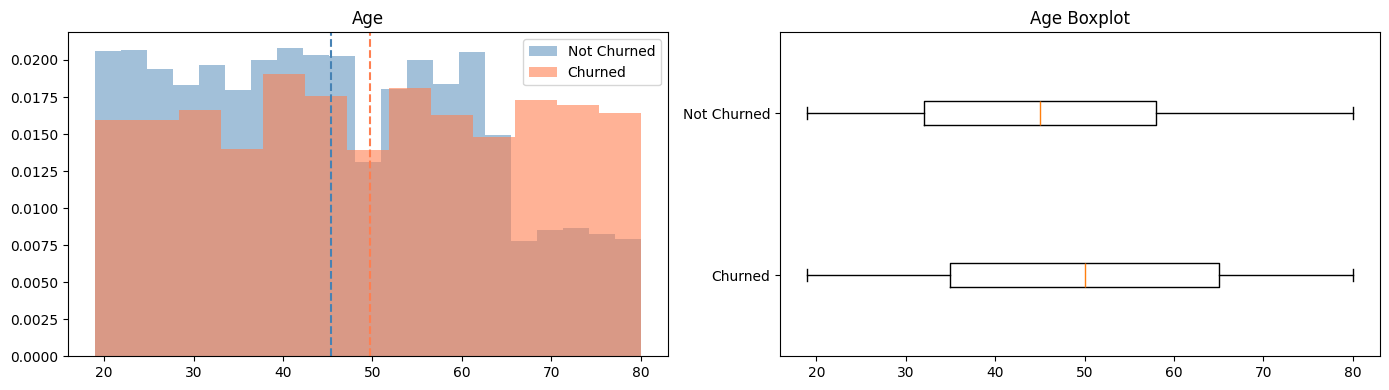

               Churned Not Churned
------------------------------------
mean             49.74       45.34
std              17.60       16.28
min              19.00       19.00
50%              50.00       45.00
max              80.00       80.00



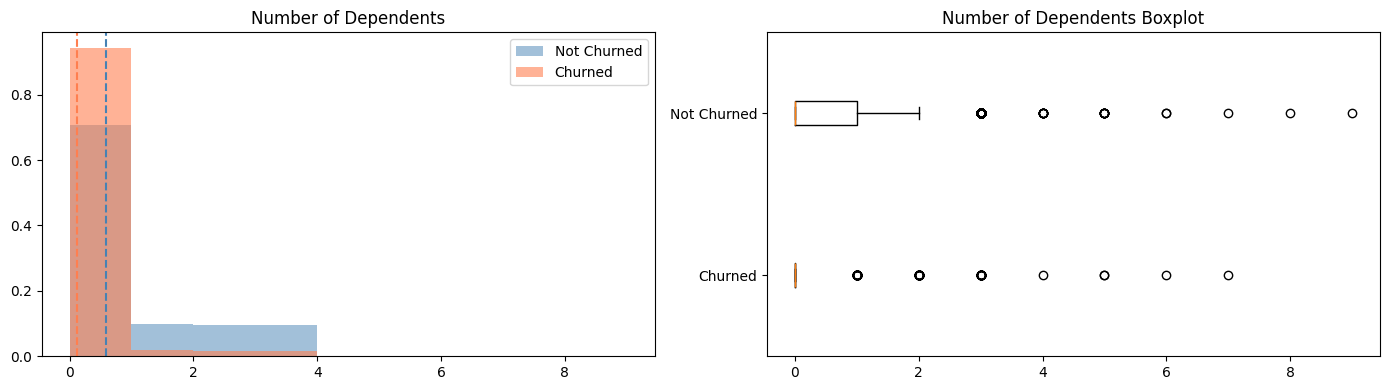

               Churned Not Churned
------------------------------------
mean              0.12        0.60
std               0.55        1.05
min               0.00        0.00
50%               0.00        0.00
max               7.00        9.00



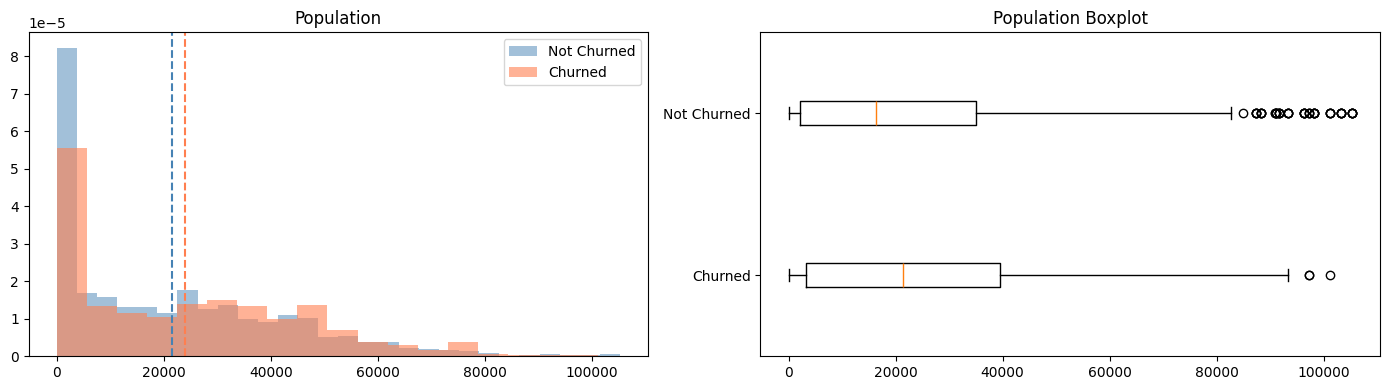

               Churned Not Churned
------------------------------------
mean          23957.21    21483.03
std           21390.49    21029.21
min              11.00       11.00
50%           21349.00    16377.50
max          101215.00   105285.00



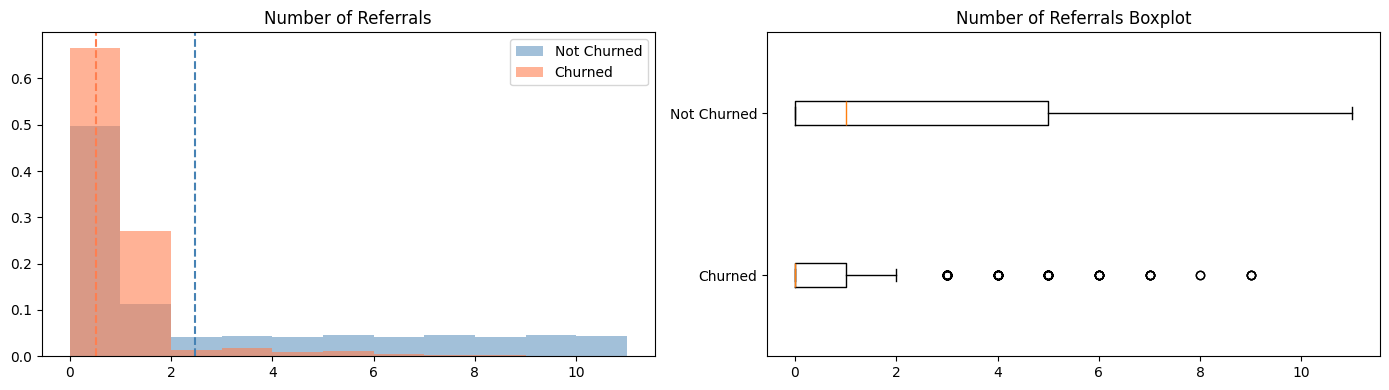

               Churned Not Churned
------------------------------------
mean              0.52        2.47
std               1.09        3.29
min               0.00        0.00
50%               0.00        1.00
max               9.00       11.00



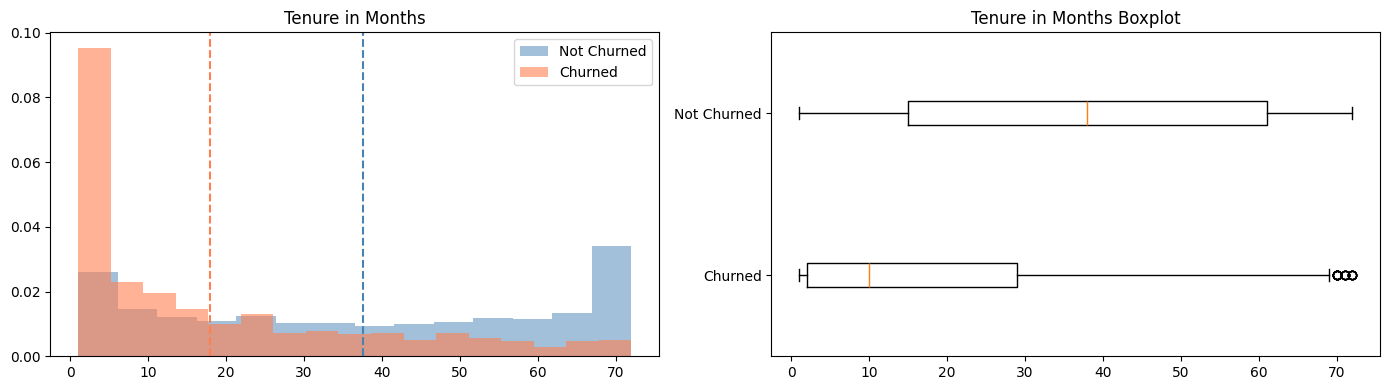

               Churned Not Churned
------------------------------------
mean             17.98       37.59
std              19.53       24.09
min               1.00        1.00
50%              10.00       38.00
max              72.00       72.00



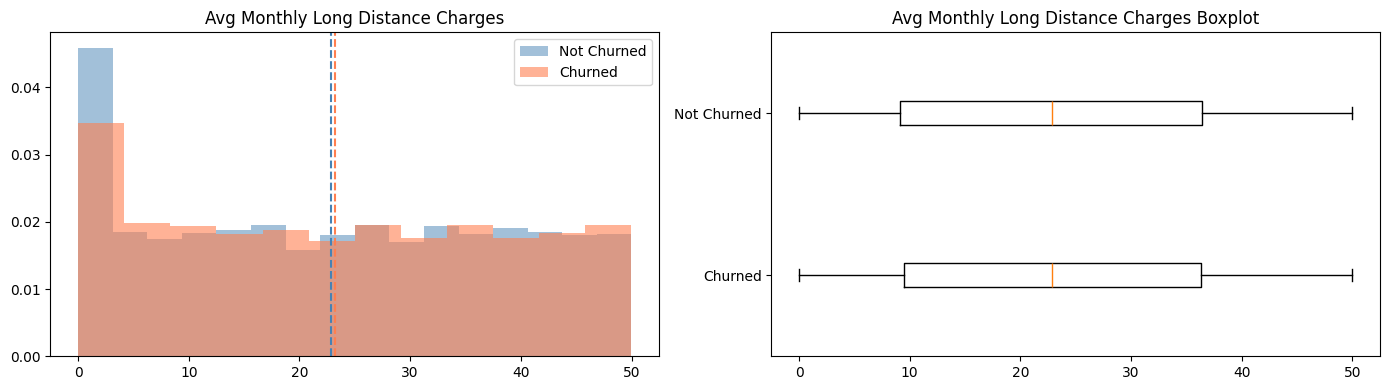

               Churned Not Churned
------------------------------------
mean             23.17       22.88
std              15.41       15.46
min               0.00        0.00
50%              22.88       22.89
max              49.98       49.99



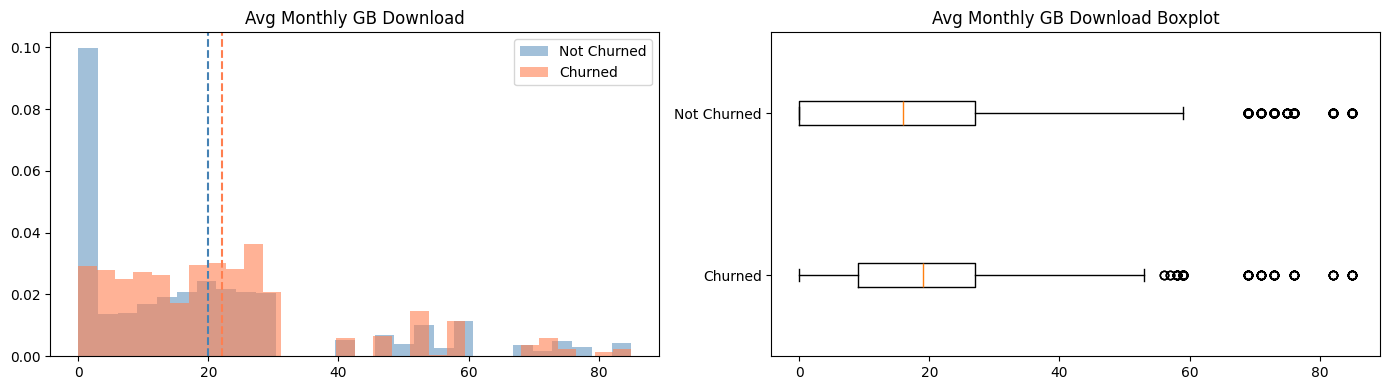

               Churned Not Churned
------------------------------------
mean             22.18       19.92
std              18.31       21.10
min               0.00        0.00
50%              19.00       16.00
max              85.00       85.00



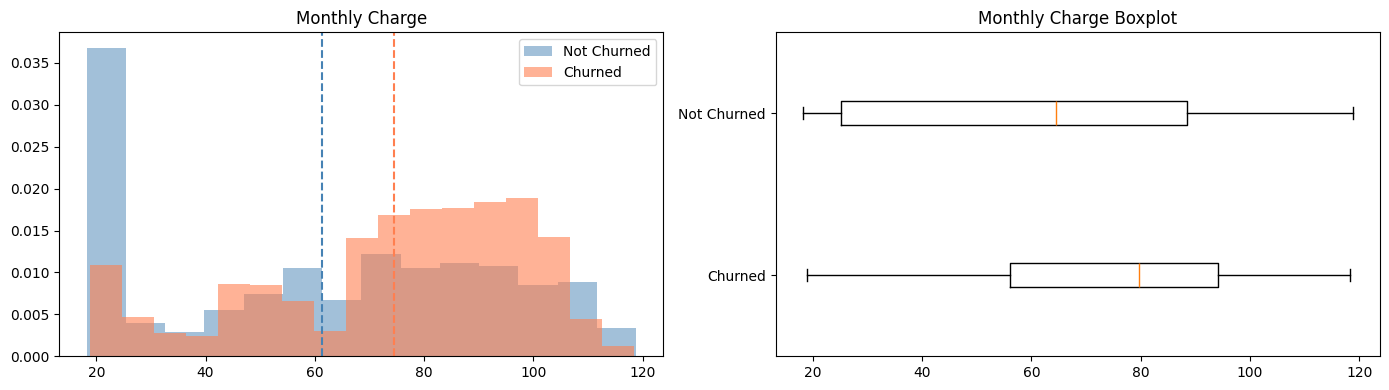

               Churned Not Churned
------------------------------------
mean             74.44       61.27
std              24.67       31.09
min              18.85       18.25
50%              79.65       64.43
max             118.35      118.75



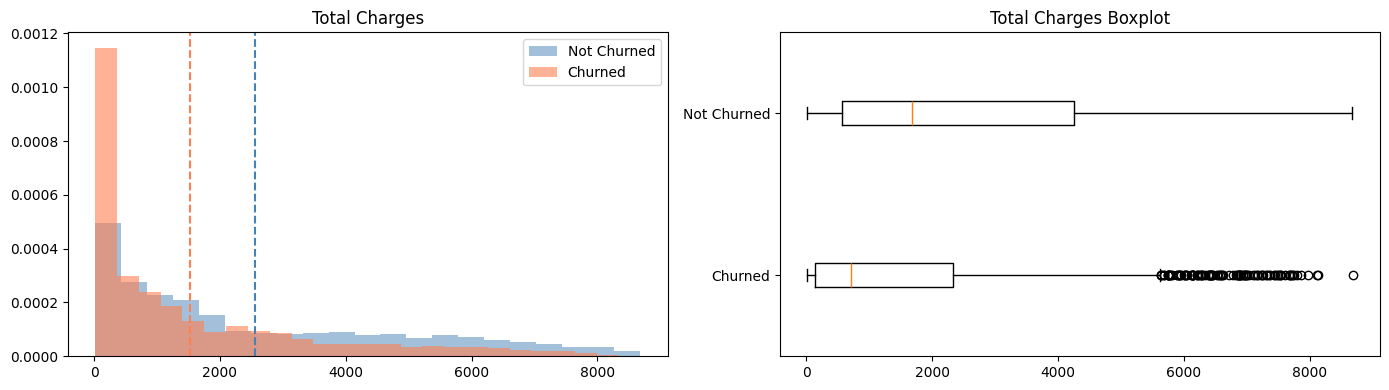

               Churned Not Churned
------------------------------------
mean           1531.80     2550.79
std            1890.82     2329.09
min              18.85       18.80
50%             703.55     1679.53
max            8684.80     8672.45



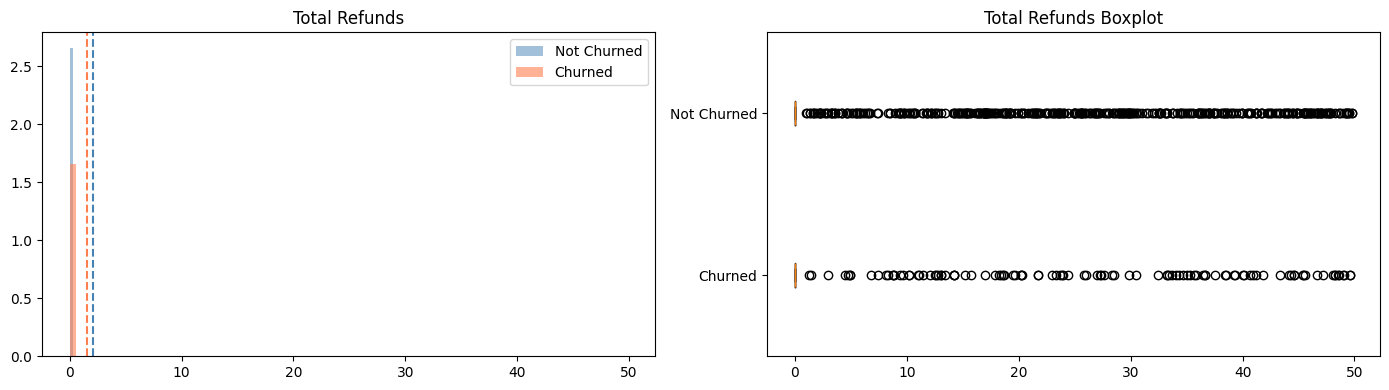

               Churned Not Churned
------------------------------------
mean              1.52        2.12
std               7.04        8.19
min               0.00        0.00
50%               0.00        0.00
max              49.57       49.79



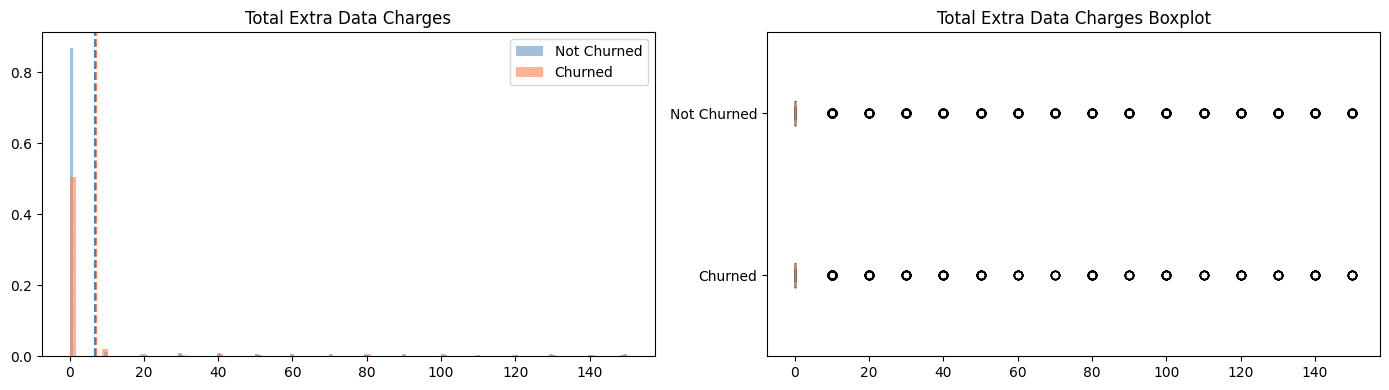

               Churned Not Churned
------------------------------------
mean              7.16        6.75
std              24.86       25.20
min               0.00        0.00
50%               0.00        0.00
max             150.00      150.00



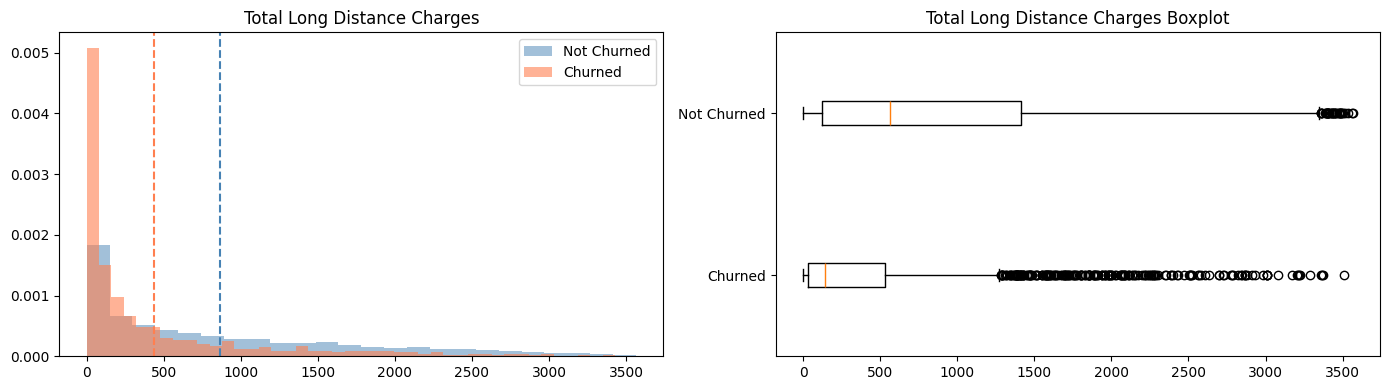

               Churned Not Churned
------------------------------------
mean            433.92      862.95
std             650.36      879.90
min               0.00        0.00
50%             139.08      564.62
max            3508.82     3564.72



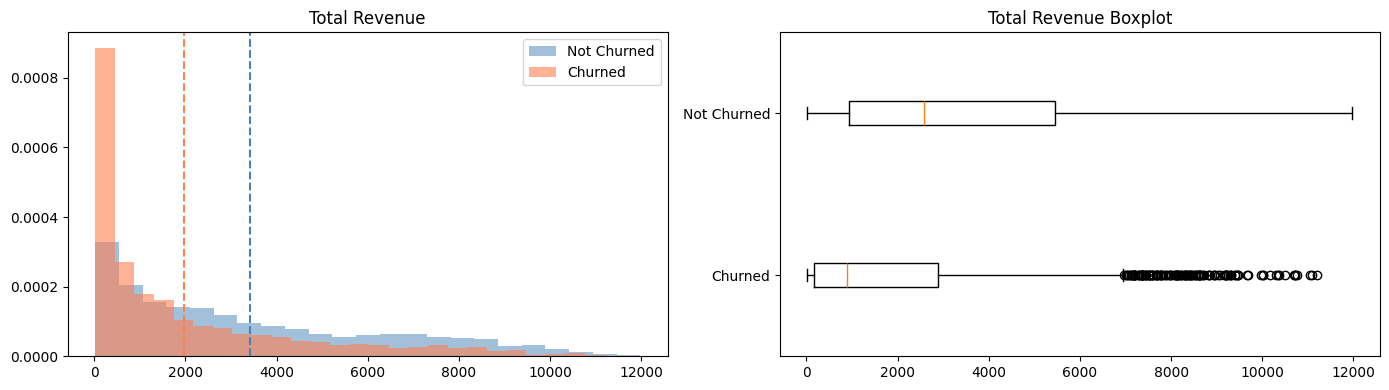

               Churned Not Churned
------------------------------------
mean           1971.35     3418.37
std            2438.44     2910.76
min              21.61       21.36
50%             893.55     2579.32
max           11195.44    11979.34



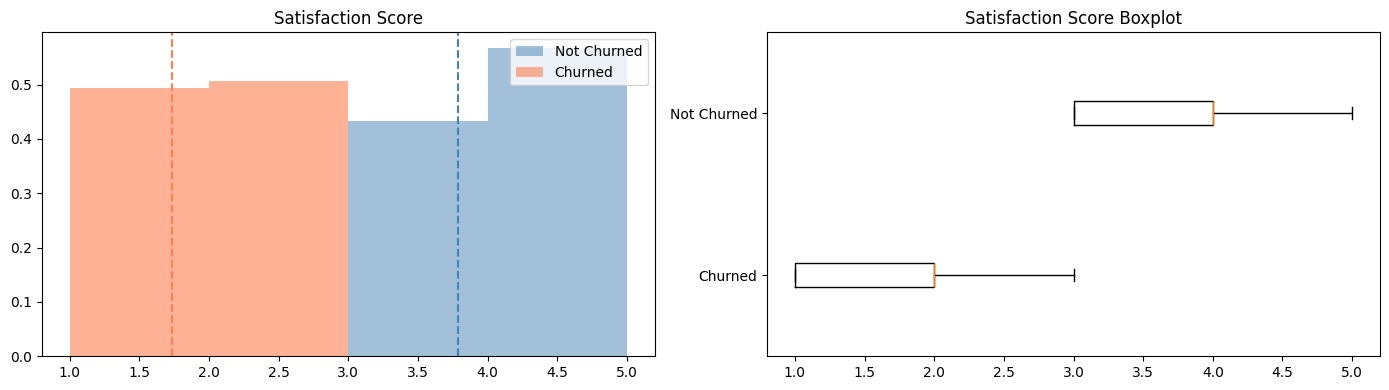

               Churned Not Churned
------------------------------------
mean              1.74        3.79
std               0.81        0.78
min               1.00        3.00
50%               2.00        4.00
max               3.00        5.00



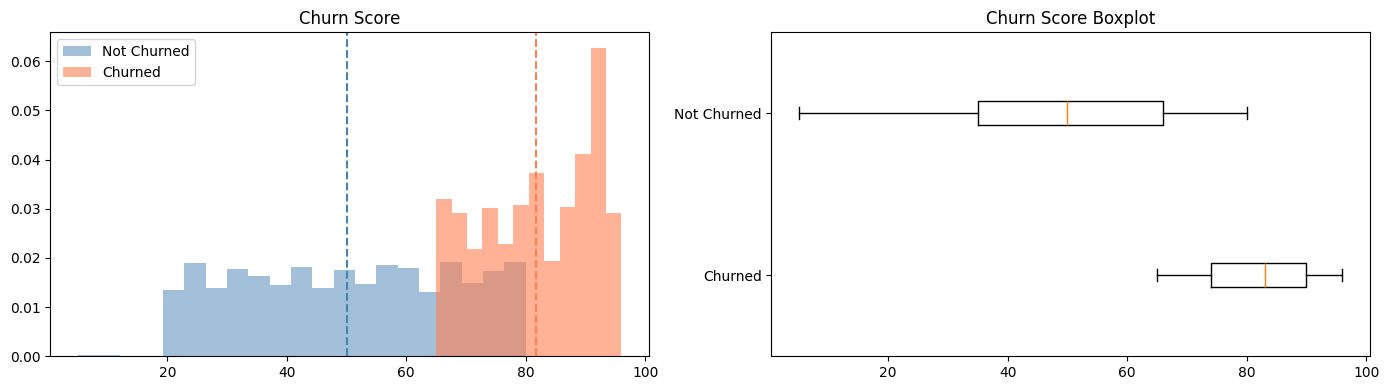

               Churned Not Churned
------------------------------------
mean             81.78       50.10
std               9.17       17.70
min              65.00        5.00
50%              83.00       50.00
max              96.00       80.00



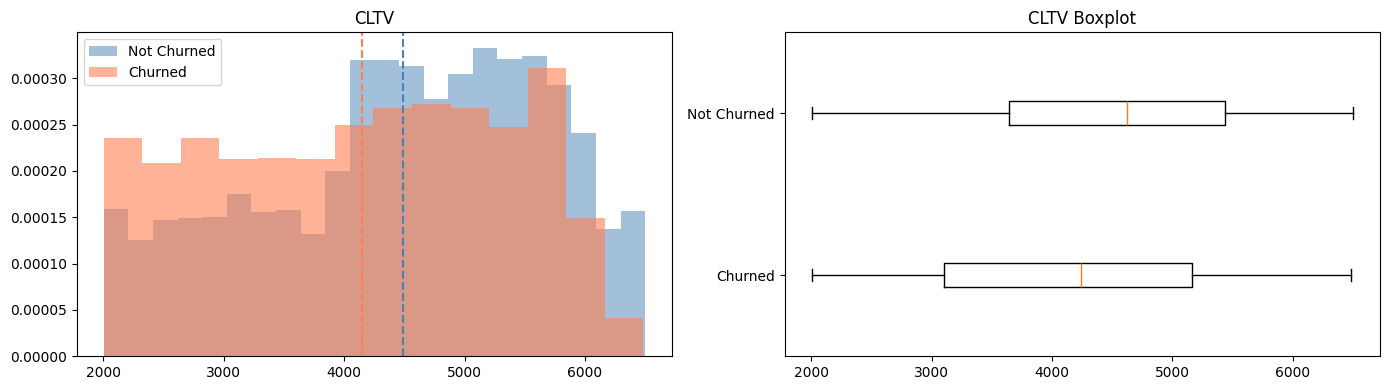

               Churned Not Churned
------------------------------------
mean           4149.41     4490.92
std            1189.37     1167.70
min            2003.00     2003.00
50%            4238.00     4620.00
max            6484.00     6500.00



In [29]:
num_cols=[c for c in numerical if c not in cols_to_skip]
for col in num_cols:
    plot_distribution(df_churned, df_not_churned,col)

In [30]:
rows = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_count = len(df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)])
    skewness = df[col].skew()
    
    rows.append({
        'Feature': col,
        'Range': f"{df[col].min():.1f} - {df[col].max():.1f}",
        'skewness': round(skewness,2),
        'Distribution': 'Normal' if abs(skewness) < 0.5 else 'Right Skewed' if skewness > 0 else 'Left Skewed',
        'IQR Flagged': outlier_count,
        'True Outliers': 'No',  # we fill this manually after judgment
        'Churn Predictor': 'TBD'  # we fill this manually
    })

true_outliers={
    'Age': 'No',
    'Number of Dependents':'No (Valid family sizes)',
    'Population': 'No (can have higher in urban)',
    'Number of Referrals': 'No(valid)',
    'Tenure in Months':'No (valid)',
    'Avg Monthly Long Distance Charges':'No',
    'Avg Monthly GB Download':'No',
    'Monthly Charge': 'No',
    'Total Charges':'No',
    'Total Refunds':'No (concen in 0 valid)',
    'Total Extra Data Charges':'No (concen in 0 valid)',
    'Total Long Distance Charges':'Possible (Heavy Right Skewed)',
    'Total Revenue': 'Possible',
    'Satisfaction Score':'No',
    'Churn Score':'No',
    'CLTV':'No'
}

predictor_strength={
    'Age':'Weak',
    'Number of Dependents':'Moderate',
    'Population': 'Weak',
    'Number of Referrals':'Strong',
    'Tenure in Months':'Strong',
    'Avg Monthly Long Distance Charges': 'Weak',
    'Avg Monthly GB Download':'Weak',
    'Monthly Charge':'Strong',
    'Total Charges':'Good',
    'Total Refunds':'Weak',
    'Total Extra Data Charges':'Weak',
    'Total Long Distance Charges':'Moderate',
    'Total Revenue': 'Good',
    'Satisfaction Score':'Strongest',
    'Churn Score': 'Leakage',
    'CLTV': 'Weak'
}
summary_table = pd.DataFrame(rows)

summary_table['True Outliers']=summary_table['Feature'].map(true_outliers)
summary_table ['Churn Predictor']=summary_table['Feature'].map(predictor_strength)

summary_table 

,Feature,Range,skewness,Distribution,IQR Flagged,True Outliers,Churn Predictor
0,Age,19.0 - 80.0,0.16,Normal,0,No,Weak
1,Number of Dependents,0.0 - 9.0,2.11,Right Skewed,1627,No (Valid family sizes),Moderate
2,Population,11.0 - 105285.0,0.91,Right Skewed,57,No (can have higher in urban),Weak
3,Number of Referrals,0.0 - 11.0,1.45,Right Skewed,676,No(valid),Strong
4,Tenure in Months,1.0 - 72.0,0.24,Normal,0,No (valid),Strong
5,Avg Monthly Long Distance Charges,0.0 - 50.0,0.05,Normal,0,No,Weak
6,Avg Monthly GB Download,0.0 - 85.0,1.22,Right Skewed,362,No,Weak
7,Monthly Charge,18.2 - 118.8,-0.22,Normal,0,No,Strong
8,Total Charges,18.8 - 8684.8,0.96,Right Skewed,0,No,Good
9,Total Refunds,0.0 - 49.8,4.33,Right Skewed,525,No (concen in 0 valid),Weak


---

### Categorical Columns

In [31]:
cat_cols=[col for col in categorical if col not in cols_to_skip]
print(f"categorical features: {len(cat_cols)}")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

categorical features: 23

Gender:
Gender
Male      3555
Female    3488
Name: count, dtype: int64

Under 30:
Under 30
No     5642
Yes    1401
Name: count, dtype: int64

Senior Citizen:
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64

Married:
Married
No     3641
Yes    3402
Name: count, dtype: int64

Dependents:
Dependents
No     5416
Yes    1627
Name: count, dtype: int64

City:
City
Los Angeles         293
San Diego           285
San Jose            112
Sacramento          108
San Francisco       104
                   ... 
Jacumba               2
South Lake Tahoe      2
Johannesburg          2
Eldridge              2
Holtville             2
Name: count, Length: 1106, dtype: int64

Referred a Friend:
Referred a Friend
No     3821
Yes    3222
Name: count, dtype: int64

Phone Service:
Phone Service
Yes    6361
No      682
Name: count, dtype: int64

Multiple Lines:
Multiple Lines
No     4072
Yes    2971
Name: count, dtype: int64

Internet Service:
Internet Service
Yes    

#### City seems to have a lot of values, lets dive deep into it.

In [32]:
df['City'].nunique()                        # count unique cities


1106

In [33]:
df['City'].value_counts()                   #count per city

City
Los Angeles         293
San Diego           285
San Jose            112
Sacramento          108
San Francisco       104
                   ... 
Jacumba               2
South Lake Tahoe      2
Johannesburg          2
Eldridge              2
Holtville             2
Name: count, Length: 1106, dtype: int64

#### of around 7000 records there are 1106 city.

### lets dive deep into city


In [34]:
top_cities=df['City'].value_counts()
top_cities=top_cities[top_cities>=100].index
print(f"Cities kept:{list(top_cities)}")
print(f"Number of cities kept: {len(top_cities)}")

# grouped other columns
df['City_Grouped']=df['City'].apply(lambda x:x if x in top_cities else 'Other')

# Check results
print("\nValue counts after grouping:")
print(df['City_Grouped'].value_counts())
print(f"\n Reduced from 1106 to {df['City_Grouped'].unique()} unique values")


Cities kept:['Los Angeles', 'San Diego', 'San Jose', 'Sacramento', 'San Francisco']
Number of cities kept: 5

Value counts after grouping:
City_Grouped
Other            6141
Los Angeles       293
San Diego         285
San Jose          112
Sacramento        108
San Francisco     104
Name: count, dtype: int64

 Reduced from 1106 to ['Los Angeles' 'Other' 'San Diego' 'San Francisco' 'San Jose' 'Sacramento'] unique values


In [35]:
df.value_counts()

Customer ID  Gender  Age  Under 30  Senior Citizen  Married  Dependents  Number of Dependents  City            Zip Code  Latitude   Longitude    Population  Referred a Friend  Number of Referrals  Tenure in Months  Phone Service  Avg Monthly Long Distance Charges  Multiple Lines  Internet Service  Internet Type  Avg Monthly GB Download  Online Security  Online Backup  Device Protection Plan  Premium Tech Support  Streaming TV  Streaming Movies  Streaming Music  Unlimited Data  Contract        Paperless Billing  Payment Method   Monthly Charge  Total Charges  Total Refunds  Total Extra Data Charges  Total Long Distance Charges  Total Revenue  Satisfaction Score  Customer Status  Churn Label  Churn Score  CLTV  City_Grouped
0002-ORFBO   Female  37   No        No              Yes      No          0                     Frazier Park    93225     34.827662  -118.999073  4498        Yes                2                    9                 Yes            42.39                              No 

In [36]:
(6141/7043) * 100 

87.19295754650007

#### Although grouping top cities was considered, the 'Other' category contain 87% of records with no meaningful signal. Hence, I have decided to drop this column

In [37]:
cols_to_skip.append('City')

df=df.drop(columns='City')

cat_cols=[col for col in categorical if col not in cols_to_skip]
num_cols=[col for col in numerical if col not in cols_to_skip]

print(f"numerical: {len(numerical)}")
print(f"Categorical: {len(categorical)}")



numerical: 19
Categorical: 25


---

#### Visualizing the Categorical Column

In [ ]:
cat_cols_filtered=[col for col in cat_cols if col!='Churn Label']

In [ ]:
print(cat_cols_filtered)

['Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Referred a Friend', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method']


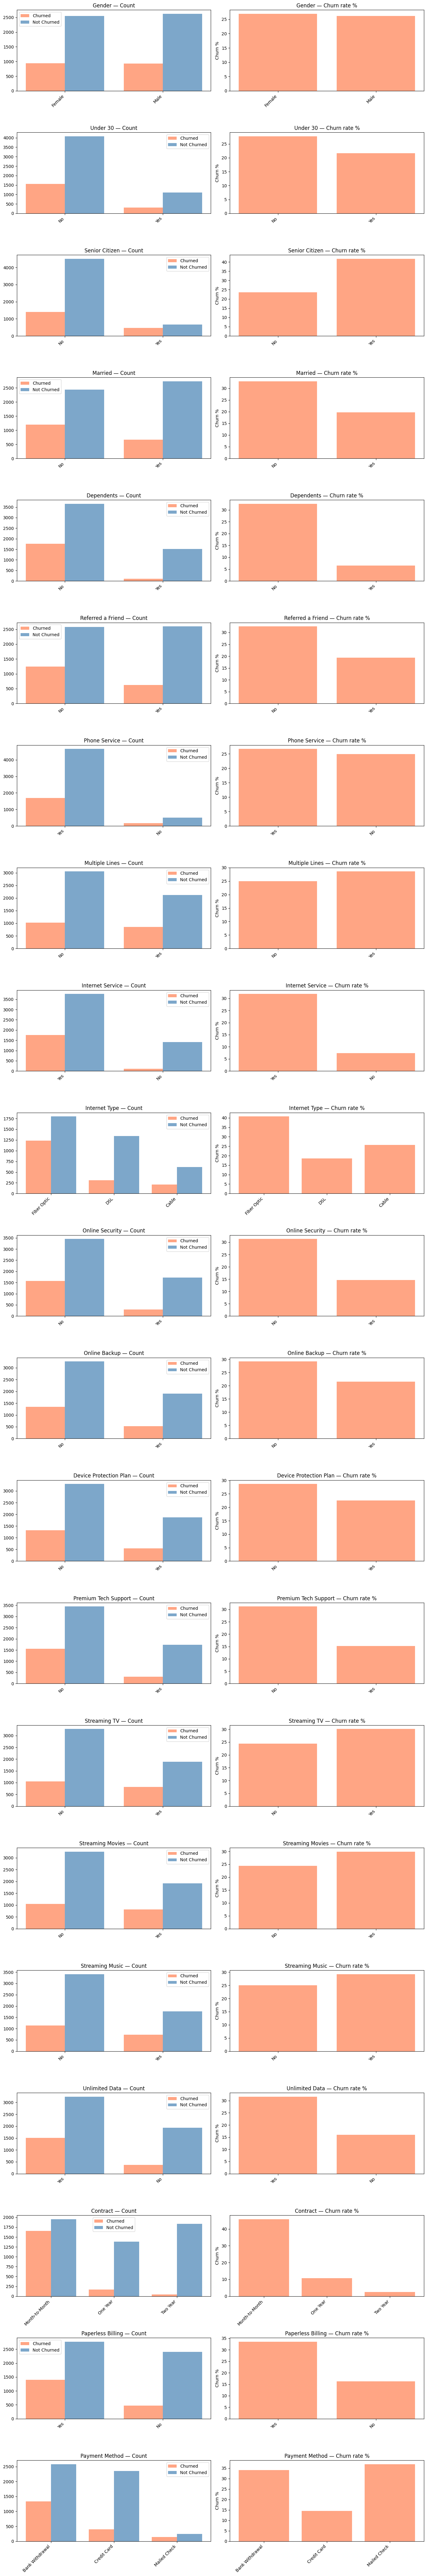

In [ ]:


fig, axes = plt.subplots(len(cat_cols_filtered), 2, figsize=(14, 4 * len(cat_cols_filtered)))                   #creating a grid

#looping i,col from the list of cat_cols_filtered
for i, col in enumerate(cat_cols_filtered):
    churned_counts = df_churned[col].value_counts()
    not_churned_counts = df_not_churned[col].value_counts()
    categories = churned_counts.index.union(not_churned_counts.index)

    x = range(len(categories))
    width = 0.4

    # Left: raw counts
    axes[i, 0].bar([j - width/2 for j in x], [churned_counts.get(c, 0) for c in categories],                        #plotting the bars
                width, color='coral', alpha=0.7, label='Churned')
    axes[i, 0].bar([j + width/2 for j in x], [not_churned_counts.get(c, 0) for c in categories],
                width, color='steelblue', alpha=0.7, label='Not Churned')
    axes[i, 0].set_xticks(list(x))
    axes[i, 0].set_xticklabels(categories, rotation=45, ha='right')
    axes[i, 0].set_title(f'{col} — Count')
    axes[i, 0].legend()

    # Right: churn rate %
    churn_rate = [
        churned_counts.get(c, 0) / (churned_counts.get(c, 0) + not_churned_counts.get(c, 0)) * 100
        for c in categories
    ]
    axes[i, 1].bar(list(x), churn_rate, color='coral', alpha=0.7, edgecolor='none')
    axes[i, 1].set_xticks(list(x))
    axes[i, 1].set_xticklabels(categories, rotation=45, ha='right')
    axes[i, 1].set_title(f'{col} — Churn rate %')
    axes[i, 1].set_ylabel('Churn %')

plt.tight_layout()
plt.show()

#### <b> Observation- Categorical Features </b>


Contract type is the strongest categorical predictor: month-to-month customers 
churn at roughly 3x the rate of customers on longer contracts. Dependents is 
also a strong predictor — customers without dependents churn at a much higher 
rate, likely because family customers are less likely to switch providers.
Internet type, payment method, and the absence of add-on services (online 
security, device protection, tech support) also show meaningful churn rate 
differences and are likely to be useful features for the ML model. Gender shows 
no meaningful separation and is expected to contribute little predictive power.



---

#### Data cleaning for Machine Learning

In [54]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Zip Code', 'Latitude',
       'Longitude', 'Population', 'Referred a Friend', 'Number of Referrals',
       'Tenure in Months', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'City_Grouped'],
      dtype='object')

##### We have to drop some columns with high cardinality and leakage values

#### Before that I want to explore the Zip code column

In [58]:
df['Zip Code'].value_counts()

Zip Code
92028    43
92027    38
92122    36
92117    34
92126    32
         ..
93528     2
91934     2
92105     2
92250     2
93711     1
Name: count, Length: 1626, dtype: int64

##### Zip Code has 1626 unique values across ~7000 records, that is too high cardinality to one hot encode and not meaning as a raw numnber. Hence I will drop this column

#### Exploring Latitude and longtitude (Potential better subsititute for the Zip code) for geographic representation

In [60]:
df['Latitude'].value_counts()

Latitude
33.362575    43
33.141265    38
32.857230    36
32.825086    34
32.886925    32
             ..
35.363339     2
32.649787     2
32.741859     2
32.811001     2
36.833002     1
Name: count, Length: 1626, dtype: int64

In [61]:
df['Longitude'].value_counts()

Longitude
-117.299644    43
-116.967221    38
-117.209774    36
-117.199424    34
-117.152162    32
               ..
-117.637641     2
-120.106169     2
-122.516990     2
-115.152865     2
-119.829470     1
Name: count, Length: 1625, dtype: int64

##### Both latitude and longitude is mapped by each zip code hence , the latitude, longtitude and zip code everything is removed for the machine learning part

#### Dropping the columns

In [64]:
print(f"Before dropping the columns, the shape of the dataframe is {df.shape}")

Before dropping the columns, the shape of the dataframe is (7043, 44)


In [68]:
cols_to_drop=['Customer ID','Zip Code','Churn Score','Customer Status', 'CLTV', 'City_Grouped','Latitude','Longitude']

df=df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("Columns dropped!!! The new shape of the dataframe is \n")
print(df.shape)

Columns dropped!!! The new shape of the dataframe is 

(7043, 36)


---

#### Encoding the target

In [70]:
df['Churn Label']=(df['Churn Label']=='Yes').astype(int)
print(df['Churn Label'].value_counts())

Churn Label
0    5174
1    1869
Name: count, dtype: int64


---

### One hot Encoding the Categorical Variables

In [73]:
cat_cols_final=df.select_dtypes(include='object').columns.tolist()
print('Encoding:',cat_cols_final)

# getting dummy variables
df_ml=pd.get_dummies(df,columns=cat_cols_final,drop_first=True)
print(df_ml.shape)

Encoding: ['Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Referred a Friend', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method']
(7043, 40)


In [74]:
df_ml.head()

,Age,Number of Dependents,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,...,Premium Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Streaming Music_Yes,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check
0,78,0,68701,0,1,0.00,8,39.65,39.65,0.00,...,False,False,True,False,False,False,False,True,False,False
1,74,1,55668,1,8,48.85,17,80.65,633.30,0.00,...,False,False,False,False,True,False,False,True,True,False
2,71,3,47534,0,18,11.33,52,95.45,1752.55,45.61,...,False,True,True,True,True,False,False,True,False,False
3,78,1,27778,1,25,19.76,12,98.50,2514.50,13.43,...,False,True,True,False,True,False,False,True,False,False
4,80,1,26265,1,37,6.33,14,76.50,2868.15,0.00,...,False,False,False,False,True,False,False,True,False,False


In [77]:
df_ml.dtypes

Age                                    int64
Number of Dependents                   int64
Population                             int64
Number of Referrals                    int64
Tenure in Months                       int64
Avg Monthly Long Distance Charges    float64
Avg Monthly GB Download                int64
Monthly Charge                       float64
Total Charges                        float64
Total Refunds                        float64
Total Extra Data Charges               int64
Total Long Distance Charges          float64
Total Revenue                        float64
Satisfaction Score                     int64
Churn Label                            int64
Gender_Male                             bool
Under 30_Yes                            bool
Senior Citizen_Yes                      bool
Married_Yes                             bool
Dependents_Yes                          bool
Referred a Friend_Yes                   bool
Phone Service_Yes                       bool
Multiple L

#### let's make boolean 0,1 rather than true/ False, even if its not necessary for sklearn's Random forest model, as we are going to go for logistic regression as a baseline model 

In [78]:
df_ml=df_ml.astype({col: int for col in df_ml.select_dtypes(include='bool').columns})
print(df_ml.dtypes.value_counts())

int64      34
float64     6
Name: count, dtype: int64


----

### Rescaling 

Rescaling is particularly important for the Logistic regression model, as it transforms all numerical features to the same scale and prevent the features with larger scale to dominate and overshadow smaller scale features,
as Logistic Regression model finds the best coefficients using gradient descents.

Standard Scaler converts every features to have mean =0 and standard deviation=1

In [79]:
from sklearn.preprocessing import StandardScaler

In [80]:
num_cols_ml=[col for col in df_ml.select_dtypes(include=['int64','float64']).columns if col!='Churn Label']         #filtering the numerical_cols

scaler=StandardScaler()                 #creating the instance
df_ml[num_cols_ml]=scaler.fit_transform(df_ml[num_cols_ml])
df_ml.head()

,Age,Number of Dependents,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,...,Premium Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Streaming Music_Yes,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check
0,1.880110,-0.486835,2.201392,-0.650409,-1.278988,-1.486303,-0.612975,-0.834611,-0.988823,-0.248313,...,-0.639439,-0.790132,1.256171,-0.739062,-1.436955,-0.531204,-0.604088,0.829798,-0.800122,-0.240469
1,1.641292,0.551874,1.585200,-0.317185,-0.993743,1.676120,-0.172176,0.528063,-0.726848,-0.248313,...,-0.639439,-0.790132,-0.796070,-0.739062,0.695916,-0.531204,-0.604088,0.829798,1.249809,-0.240469
2,1.462179,2.629292,1.200630,-0.650409,-0.586250,-0.752828,1.542040,1.019955,-0.232929,5.523605,...,-0.639439,1.265612,1.256171,1.353066,0.695916,-0.531204,-0.604088,0.829798,-0.800122,-0.240469
3,1.880110,0.551874,0.266580,-0.317185,-0.301005,-0.207092,-0.417064,1.121324,0.103315,1.451245,...,-0.639439,1.265612,1.256171,-0.739062,0.695916,-0.531204,-0.604088,0.829798,-0.800122,-0.240469
4,1.999519,0.551874,0.195046,-0.317185,0.187986,-1.076516,-0.319109,0.390134,0.259379,-0.248313,...,-0.639439,-0.790132,-0.796070,-0.739062,0.695916,-0.531204,-0.604088,0.829798,-0.800122,-0.240469


----

### Divinding the dataframe into train, test, and validation split

Train set-> model learns from this data <br>
validation set --> it is for tuning and evaluating the model during development without touching the test set <br>
Test set --> used once at the very end to report the final performance.


In [81]:
from sklearn.model_selection import train_test_split

In [82]:
X=df_ml.drop(columns=['Churn Label'])
Y=df_ml['Churn Label']

# first splitting off the test set(15%)

X_temp, X_test, Y_temp, Y_test=train_test_split(X, Y, test_size=0.15,stratify=Y,random_state=42)

#splitting the remaining into train and validation set 

X_train, X_val, Y_train, Y_val= train_test_split(X_temp,Y_temp,test_size=0.18,stratify=Y_temp,random_state=42)
#used test_size-0.18 to get precise 70/15/15 split as 0.15/0.85(x-temp)=0.18

print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

Train: (4908, 39)
Validation: (1078, 39)
Test: (1057, 39)
